In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from pathlib import Path

In [7]:
# Load the uploaded dataset
file_path = "L_W_variables.csv"
df = pd.read_csv(file_path)
df = df.drop(columns=["S.No"])


In [9]:
print("Dataset shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

Dataset shape: (676, 4)

Columns:
['L', 'W', 'F', 'S11']


In [10]:
print("\nFirst 10 rows:")
display(df.head(10))


First 10 rows:


,L,W,F,S11
0,16.24,22.66,4.24,-17.358022
1,16.64,22.66,4.14,-17.071609
2,17.04,22.66,4.06,-16.999123
3,17.44,22.66,3.99,-16.791115
4,17.84,22.66,3.90,-16.537894
5,18.24,22.66,3.84,-16.501350
6,18.64,22.66,3.76,-16.103861
7,19.04,22.66,3.69,-15.948546
8,19.44,22.66,3.63,-15.695085
9,19.84,22.66,3.56,-15.355396


In [12]:
print("\nData types:")
print(df.dtypes)


Data types:
L      float64
W      float64
F      float64
S11    float64
dtype: object


In [14]:

print("\nMissing values:")
print(df.isnull().sum())


Missing values:
L      0
W      0
F      0
S11    0
dtype: int64


In [13]:
print("\nBasic statistics:")
display(df.describe())


Basic statistics:


,L,W,F,S11
count,676.000000,676.000000,676.000000,676.000000
mean,21.240000,27.660000,3.794438,-17.564635
std,3.002221,3.002221,0.647017,9.606007
min,16.240000,22.660000,2.650000,-58.263072
25%,18.640000,25.060000,3.327500,-23.906591
50%,21.240000,27.660000,3.730000,-17.360892
75%,23.840000,30.260000,4.340000,-8.774893
max,26.240000,32.660000,5.000000,-4.424953


In [15]:
# Identify the variables for the mathematical study
features = ["L", "W", "F"]
target = "S11"

In [16]:

# Distribution statistics
print("\nS11 distribution statistics:")
s11 = df[target].dropna()
print("Mean      :", s11.mean())
print("Median    :", s11.median())
print("Std       :", s11.std())
print("Minimum   :", s11.min())
print("Maximum   :", s11.max())
print("Skewness  :", stats.skew(s11))
print("Kurtosis  :", stats.kurtosis(s11))


S11 distribution statistics:
Mean      : -17.564634907318048
Median    : -17.360892105
Std       : 9.606007195907297
Minimum   : -58.26307211
Maximum   : -4.42495316
Skewness  : -0.3790791064033641
Kurtosis  : -0.40970341871855753


In [17]:
print("\nUnique values:")
for col in features:
    print(f"{col}: {df[col].nunique()} unique values")

print("\nDuplicate rows:", df.duplicated().sum())


Unique values:
L: 26 unique values
W: 26 unique values
F: 209 unique values

Duplicate rows: 0


In [18]:

# Correlation matrix
print("\nCorrelation matrix:")
display(df[features + [target]].corr())


Correlation matrix:


,L,W,F,S11
L,1.000000e+00,-2.960595e-16,-0.027072,0.402835
W,-2.960595e-16,1.000000e+00,0.456102,-0.305357
F,-2.707182e-02,4.561025e-01,1.000000,-0.346635
S11,4.028346e-01,-3.053567e-01,-0.346635,1.000000


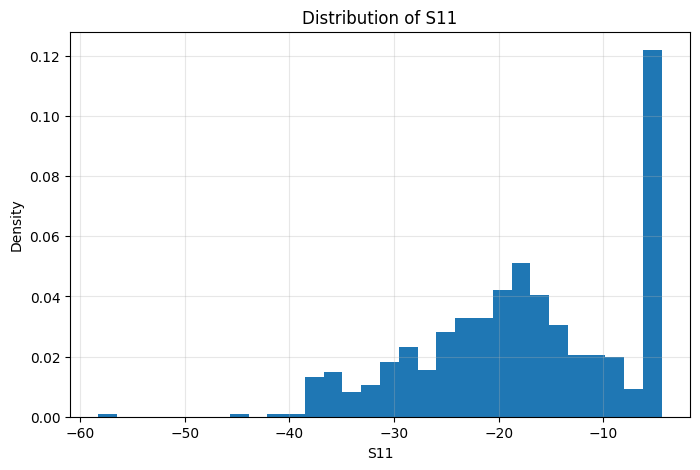

In [19]:
# Plot S11 distribution
plt.figure(figsize=(8, 5))
plt.hist(s11, bins=30, density=True)
plt.xlabel("S11")
plt.ylabel("Density")
plt.title("Distribution of S11")
plt.grid(alpha=0.3)
plt.show()


In [20]:
# KDE
x = np.linspace(s11.min(), s11.max(), 500)
kde = stats.gaussian_kde(s11)

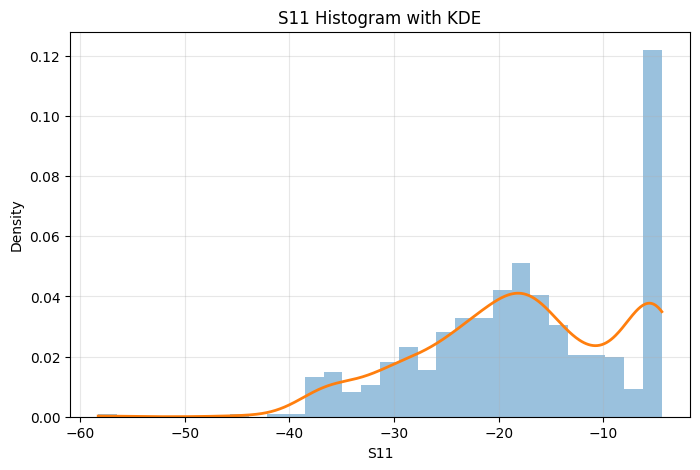

In [21]:
plt.figure(figsize=(8, 5))
plt.hist(s11, bins=30, density=True, alpha=0.45)
plt.plot(x, kde(x), linewidth=2)
plt.xlabel("S11")
plt.ylabel("Density")
plt.title("S11 Histogram with KDE")
plt.grid(alpha=0.3)
plt.show()

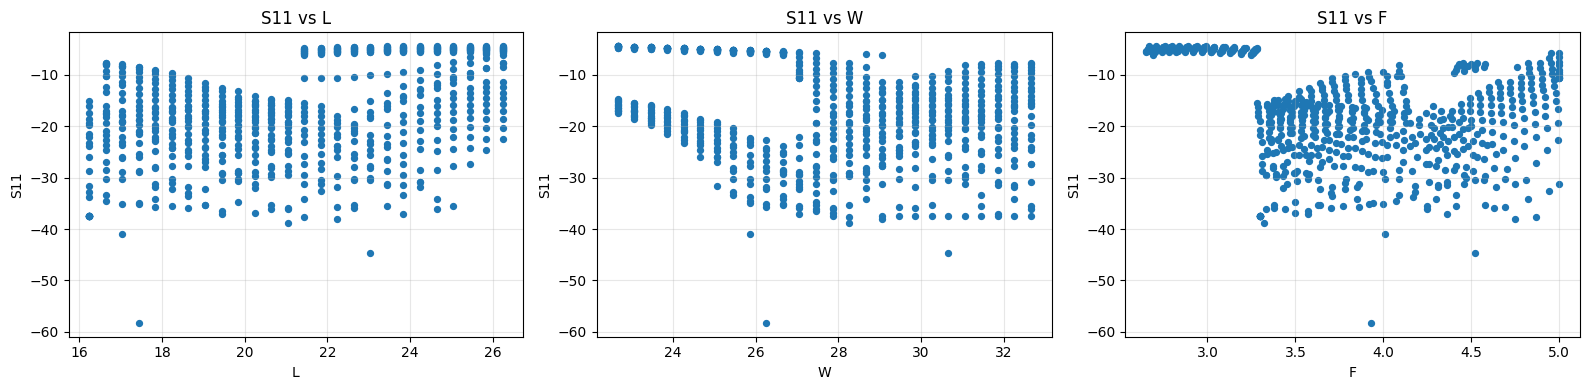

In [22]:

# Pairwise relationships
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, col in zip(axes, features):
    ax.scatter(df[col], df[target], s=18)
    ax.set_xlabel(col)
    ax.set_ylabel("S11")
    ax.set_title(f"S11 vs {col}")
    ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()
